# Projekt pierwszy, zapraszam na przejażdżkę, gdyż ten notebook zawiera w sobie całą podróż jaką odbyłem tworząc ten projekt!

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import PIL
%matplotlib inline
from pandas import DataFrame
import pandas as pd
from IPython.display import display, HTML
import plotly.graph_objects as go
from collections import Counter

In [2]:
!wget -O bronze.zip http://grail.cs.washington.edu/projects/photomontage/data/bronze.zip && unzip -o bronze.zip -d bronze

--2025-04-19 21:58:52--  http://grail.cs.washington.edu/projects/photomontage/data/bronze.zip
Resolving grail.cs.washington.edu (grail.cs.washington.edu)... 128.208.5.93, 2607:4000:200:14::5d
Connecting to grail.cs.washington.edu (grail.cs.washington.edu)|128.208.5.93|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://grail.cs.washington.edu/projects/photomontage/data/bronze.zip [following]
--2025-04-19 21:58:52--  https://grail.cs.washington.edu/projects/photomontage/data/bronze.zip
Connecting to grail.cs.washington.edu (grail.cs.washington.edu)|128.208.5.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 328148 (320K) [application/zip]
Saving to: ‘bronze.zip’

bronze.zip          100%[===================>] 320.46K  1.07MB/s    in 0.3s    

2025-04-19 21:58:53 (1.07 MB/s) - ‘bronze.zip’ saved [328148/328148]

Archive:  bronze.zip
  inflating: bronze/IMG_3083.JPG     
  inflating: bronze/IMG_3084.JPG     
  inflating: bronze/

In [3]:
# funkcje pomocnicze, ale chyba tylko do colaba, generalnie kopia z poprzednio używanych notebooków :D
if 'google.colab' in str(get_ipython()):
  from google.colab.patches import cv2_imshow
  imshow = cv2_imshow
else:
  def imshow(a):
    a = a.clip(0, 255).astype('uint8')
    if a.ndim == 3:
      if a.shape[2] == 4:
        a = cv2.cvtColor(a, cv2.COLOR_BGRA2RGBA)
      else:
        a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
    display(PIL.Image.fromarray(a))

In [4]:
def h_color(a, interpolation=None, size=None, fy=1.5, fx=1.5, cmap='gray'):
  s = [int(a.shape[0] * fy), int(a.shape[1] * fx)] if size is None else size
  plt.figure(figsize=s)
  plt.tick_params(
    axis='both', which='both',
    bottom=False, top=False,
    labelbottom=False, labelleft=False, left=False, right=False
  )
  plt.imshow(a, cmap=cmap, interpolation=interpolation)

In [5]:
css = """
<style type="text/css">
  table, td, table.dataframe, table.dataframe td {
    border: 1px solid black;    //border: double;
    border-collapse: collapse;
    border-style: solid;
    border-spacing: 0px;
    background-color: rgb(250,250,250);
    width: 24px;
    height: 24px;
    text-align: center;
    transform: scale(1.0);
    margin: 5px;
    }
</style>
"""

def h(s):
   return display(HTML(css + DataFrame(s).to_html(header=False, index=False)))

In [6]:
def h_color_3d(z):
  fig = go.Figure(data=[go.Surface(z=z)])
  fig.update_layout(autosize=False, width=500, height=500)
  fig.show()

In [7]:
# funkcje pomocnicze

def detect_max_luminance(images):
    # Przelicz RGB na luminancję (Y)
    luminance = 0.2126 * images[:, :, :, 0] + 0.7152 * images[:, :, :, 1] + 0.0722 * images[:, :, :, 2]  # (N, H, W)

    # Znajdź indeks obrazu z największą luminancją w każdym pikselu
    label_map = np.argmax(luminance, axis=0)  # (H, W)

    return label_map


def merge(images, images_masks):
  merged = np.zeros(images[0].shape, np.float32)
  weights_sum = np.zeros_like(images_masks[0], dtype=np.float32)
  weights_sum = np.expand_dims(weights_sum, axis=-1)
  for i in range(len(images)):
    mask = np.expand_dims(images_masks[i], axis=-1)
    merged += mask * images[i]
    weights_sum += mask
  merged = np.divide(merged, weights_sum, where=weights_sum > 0)
  return np.clip(merged, 0, 255).astype(np.uint8)


===
Zdjęcia figurki z różnym światłem



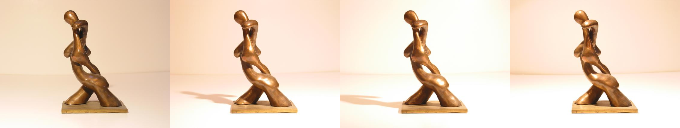

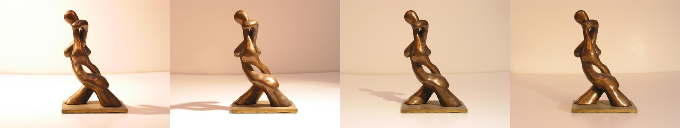

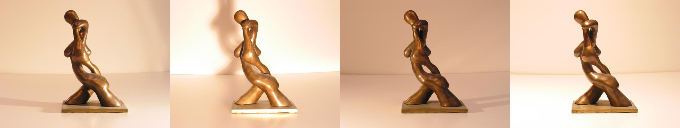

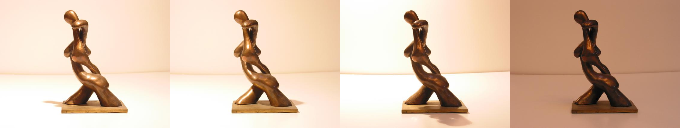

In [8]:
files = [
    './bronze/IMG_3083.JPG',
    './bronze/IMG_3084.JPG',
    './bronze/IMG_3085.JPG',
    './bronze/IMG_3086.JPG',
    './bronze/IMG_3087.JPG',
    './bronze/IMG_3088.JPG',
    './bronze/IMG_3089.JPG',
    './bronze/IMG_3090.JPG',
    './bronze/IMG_3091.JPG',
    './bronze/IMG_3092.JPG',
    './bronze/IMG_3093.JPG',
    './bronze/IMG_3094.JPG',
    './bronze/IMG_3095.JPG',
    './bronze/IMG_3096.JPG',
    './bronze/IMG_3097.JPG',
    './bronze/IMG_3098.JPG'
]

# wczytanie danych
figs = [cv2.imread(f, 1) for f in files]
figs = list(map(lambda i: cv2.resize(i, None, fx=0.3, fy=0.3), figs))

# wczytanie spodziewanego wyniku algorytmu
result = cv2.imread('./bronze/result.png', 1)
result = cv2.resize(result, None, fx=0.3, fy=0.3)

print('\n===')
print('Zdjęcia figurki z różnym światłem\n')
imshow(np.concatenate(figs[0:4], 1))
imshow(np.concatenate(figs[4:8], 1))
imshow(np.concatenate(figs[8:12], 1))
imshow(np.concatenate(figs[12:16], 1))

# Podejście pierwsze, max luminancja


===
Wynik scalania (maksymalna luminancja) porównany z oczekiwanym:



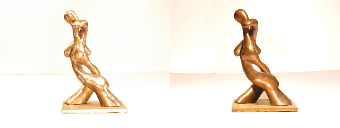

In [9]:
# Zamiana listy obrazów na tablicę NumPy
figs_np = np.stack(figs, axis=0)  # (N, H, W, 3)

# Obliczenie mapy etykiet
label_map = detect_max_luminance(figs_np)  # (H, W)

# Utworzenie masek binarnych dla każdego obrazu
images_masks = [(label_map == i).astype(np.float32) for i in range(len(figs))]

# Scalanie obrazów
merged_image = merge(figs, images_masks)


print("\n===\nWynik scalania (maksymalna luminancja) porównany z oczekiwanym:\n")
imshow(np.hstack([merged_image, result]))


# Jak widać podejście pierwsze nie działa, to może po ekspozycji?
(Coś przeczytałem w tym paperze, ale obecnie jeszcze przerażają mnie tamte metody, więc pobawię się tym i tamtym co mi wpadnie w łapki)

In [10]:
def detect_exposure_balanced(images):
    luminance = 0.2126 * images[:, :, :, 0] + 0.7152 * images[:, :, :, 1] + 0.0722 * images[:, :, :, 2]
    avg_luminance = np.mean(luminance, axis=0)  # (H, W)
    diff = np.abs(luminance - avg_luminance[None, :, :])  # (N, H, W)
    label_map = np.argmin(diff, axis=0)  # najmniejsza różnica = najbardziej "neutralna" ekspozycja
    return label_map


===
Wynik scalania (neutralna ekspozycja) porównany z oczekiwanym:



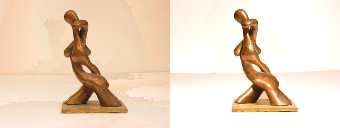

In [11]:
figs_np = np.stack(figs, axis=0)
label_map = detect_exposure_balanced(figs_np)
images_masks = [(label_map == i).astype(np.float32) for i in range(len(figs))]
merged_image = merge(figs, images_masks)

print("\n===\nWynik scalania (neutralna ekspozycja) porównany z oczekiwanym:\n")
imshow(np.hstack([merged_image, result]))


# Nie jest dobrze, ale nie jest też źle.
### Można powiedzieć, że jest średnio.

\\

No ok, jest lepiej, odrobinę, ale widać niefajne przejścia, może trzeba coś inaczej...

A co gdyby brać zamiast jednego (np max luminance) najlepsze 3, a potem je uśredniać?

In [12]:
def detect_top_k(images, k=3):
    # Oblicz luminancję (jasność) dla każdego obrazu
    luminance = (
        0.2126 * images[:, :, :, 0] +
        0.7152 * images[:, :, :, 1] +
        0.0722 * images[:, :, :, 2]
    )  # (N, H, W)

    # Znajdź indeksy top-k największych luminancji
    top_k_indices = np.argsort(-luminance, axis=0)[:k]  # (k, H, W)

    # Stwórz maski binarne dla każdego obrazu
    H, W = luminance.shape[1:]
    masks = [np.zeros((H, W), dtype=np.float32) for _ in range(images.shape[0])]

    for idx in range(k):
        for i in range(images.shape[0]):
            masks[i] += (top_k_indices[idx] == i).astype(np.float32)

    return masks  # Lista masek dla merge


===
Wynik scalania (maksymalna luminancja, n=3) porównany z oczekiwanym:



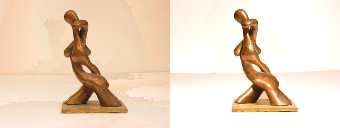

In [13]:
figs_np = np.stack(figs, axis=0)
image_masks = detect_top_k(figs_np, k=1)
merged = merge(figs_np, image_masks)

print("\n===\nWynik scalania (maksymalna luminancja, n=3) porównany z oczekiwanym:\n")
imshow(np.hstack([merged_image, result]))

# Jest ...inaczej

nie wiem czy lepiej, ale może coś tam mamy?

A, no to obejrzałem sobie filmik i doczytałem rzeczy w tym paperze.
Mam właściwie więcej pytań o to jak powinien wyglądać projekt niż miałem wcześniej, ale wychodzę z założenia że mamy nie korzystać z dostarczanego przez twórców papera software'u do zaznaczania ręcznie obszarów zainteresowań, prawda?
No bo... no bo jak tak, to właściwie, mógłbym hard-code'ować rozwiązanie.
I też jeśli mamy tego nie używać, to katedra wydaje się rzeczywiście najprostsza, bo bierze się największe prawdopodobieństwo dla każdego piksela po kolorze...

Wow jaki tamto się wydaje prosty projekt teraz.
A co gdyby spróbować po prostu dać merge na figurce? uśrednić piksele?
to będzie ciemne, prawda?

a co jeśli dać "max likelyhood", jak w podejściu z katedrą?

In [14]:
def detect_average(images):
    # Zwraca maski z jedynkami – wszystkie obrazy mają jednakową wagę - uśrednimy WSZYSTKO
    H, W = images.shape[1:3]
    masks = [np.ones((H, W), dtype=np.float32) for _ in range(images.shape[0])]
    return masks


===
Wynik scalania (average) porównany z oczekiwanym:



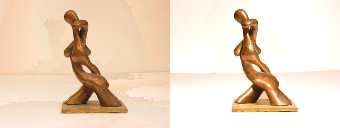

In [15]:
figs_np = np.stack(figs, axis=0)
image_masks = detect_average(figs_np)
merged = merge(figs_np, image_masks)

print("\n===\nWynik scalania (average) porównany z oczekiwanym:\n")
imshow(np.hstack([merged_image, result]))

Wynik jest spodziewany, gorzej doświetlony niż przewidywany.
Ale jeszcze ten z najczęstszym, a potem poeksperymentuję bardziej z k w tym k najlepszych i to udokumentuję!

In [16]:
def detect_majority(images):
    N, H, W, C = images.shape
    result = np.zeros((H, W, C), dtype=np.uint8)

    for y in range(H):
        for x in range(W):
            pixel_values = [tuple(images[i, y, x]) for i in range(N)]
            most_common = Counter(pixel_values).most_common(1)[0][0]
            result[y, x] = most_common

    return result


===
Wynik scalania (max likelyhood) porównany z oczekiwanym:



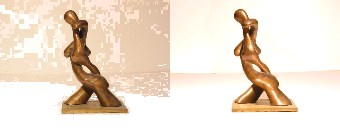

In [17]:
figs_np = np.stack(figs, axis=0)
majority_result = detect_majority(figs_np)

print("\n===\nWynik scalania (max likelyhood) porównany z oczekiwanym:\n")
imshow(np.hstack([majority_result, result]))

Ok, Majority ewidentnie potrzebowałby wygładzenia. A do tego jeszcze rozjaśnienia. To chyba nie jest droga na ten projekt, ale hej! a gdyby tak rozwiązać projekt z katedrą "po drodze"?

In [18]:
!wget -O cathedral.zip http://grail.cs.washington.edu/projects/photomontage/data/cathedral.zip && unzip -o cathedral.zip

--2025-04-19 21:58:57--  http://grail.cs.washington.edu/projects/photomontage/data/cathedral.zip
Resolving grail.cs.washington.edu (grail.cs.washington.edu)... 128.208.5.93, 2607:4000:200:14::5d
Connecting to grail.cs.washington.edu (grail.cs.washington.edu)|128.208.5.93|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://grail.cs.washington.edu/projects/photomontage/data/cathedral.zip [following]
--2025-04-19 21:58:57--  https://grail.cs.washington.edu/projects/photomontage/data/cathedral.zip
Connecting to grail.cs.washington.edu (grail.cs.washington.edu)|128.208.5.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1342082 (1.3M) [application/zip]
Saving to: ‘cathedral.zip’

cathedral.zip       100%[===================>]   1.28M  2.19MB/s    in 0.6s    

2025-04-19 21:58:58 (2.19 MB/s) - ‘cathedral.zip’ saved [1342082/1342082]

Archive:  cathedral.zip
  inflating: cathedral/d001.jpg      
  inflating: cathedral/d002.jpg      

Zdjęcia katedry



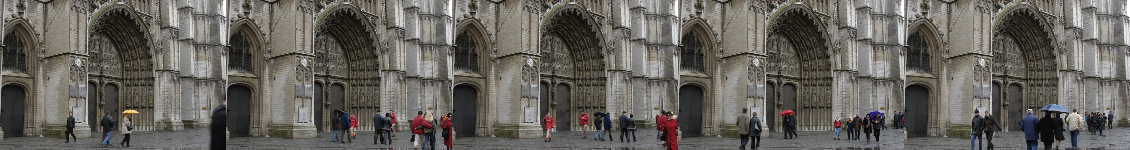


===
Zdjęcie oczekiwane



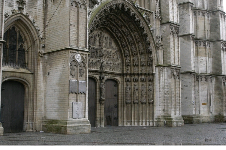

In [19]:
files = [
    './cathedral/d001.jpg',
    './cathedral/d002.jpg',
    './cathedral/d003.jpg',
    './cathedral/d004.jpg',
    './cathedral/d005.jpg'
    ]

# wczytanie danych
cath = [cv2.imread(f, 1) for f in files]
cath = list(map(lambda i: cv2.resize(i, None, fx=0.3, fy=0.3), cath))

# wczytanie spodziewanego wyniku algorytmu
cath_result = cv2.imread('./cathedral/result.png', 1)
cath_result = cv2.resize(cath_result, None, fx=0.3, fy=0.3)

print('Zdjęcia katedry\n')
imshow(np.concatenate(cath, 1))

print('\n===')
print('Zdjęcie oczekiwane\n')
imshow(cath_result)

In [21]:
def merge_by_majority(images):
    images = np.array(images)  # (N, H, W, C)
    N, H, W, C = images.shape
    result = np.zeros((H, W, C), dtype=np.uint8)

    for y in range(H):
        for x in range(W):
            # Lista wartości RGB dla danego piksela we wszystkich obrazach
            pixel_values = [tuple(images[i, y, x]) for i in range(N)]
            # Najczęściej występujący kolor
            most_common = Counter(pixel_values).most_common(1)[0][0]
            result[y, x] = most_common

    return result


===
Wynik scalania (max likelyhood) porównany z oczekiwanym, ale dla katedry:



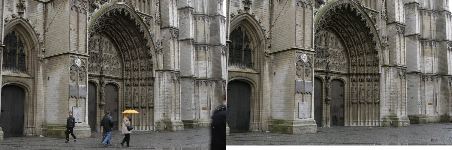


===
To samo porównanie, ale przeskalowane (większe):



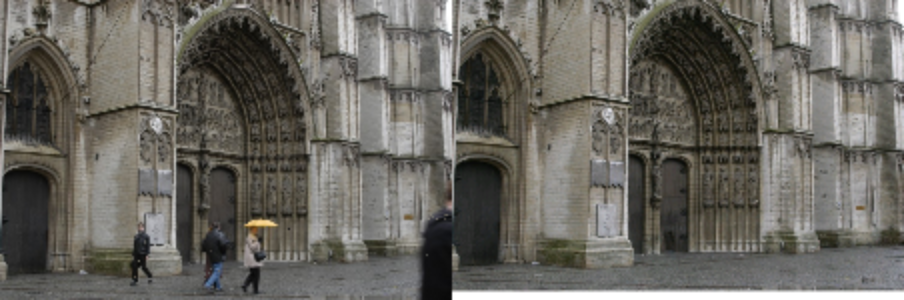

In [28]:
cath_np = np.stack(cath, axis=0)
merged_majority = merge_by_majority(cath_np)

print("\n===\nWynik scalania (max likelyhood) porównany z oczekiwanym, ale dla katedry:\n")
imshow(np.hstack([merged_majority, cath_result]))

scale = 2.0
combined = np.hstack([merged_majority, cath_result])
combined_scaled = cv2.resize(combined, None, fx=scale, fy=scale)
print("\n===\nTo samo porównanie, ale przeskalowane (większe):\n")
imshow(combined_scaled)

Hmm, no ok, wygląda mi na to, że wzięło pierwszy obraz.
Trochę tak, jakby jednak piksele nie były idealnie dokładne, więc pewnie trzeba brać najczęstszy z jakimś zaokrągleniem.

In [30]:
def merge_by_majority2(images, bin_size=10):
    images = np.array(images)  # (N, H, W, C)
    N, H, W, C = images.shape
    result = np.zeros((H, W, C), dtype=np.uint8)

    for y in range(H):
        for x in range(W):
            pixel_values = [tuple(images[i, y, x]) for i in range(N)]
            # Zaokrągl kolory do najbliższych bin_size (np. 10)
            rounded_values = [tuple((np.array(p) // bin_size * bin_size)) for p in pixel_values]

            # Znajdź najczęstszy zaokrąglony kolor
            most_common_bin = Counter(rounded_values).most_common(1)[0][0]

            # Wybierz piksel z oryginalnych, który jest najbliższy temu binowi
            best_pixel = min(pixel_values, key=lambda p: np.linalg.norm(np.array(p) - np.array(most_common_bin)))

            result[y, x] = best_pixel

    return result


===
Wynik scalania (max likelyhood) porównany z oczekiwanym, ale dla katedry, tylko z przybliżonymi kolorami:



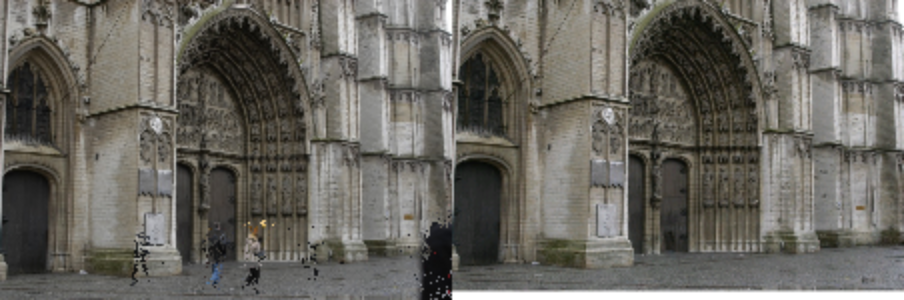

In [34]:
cath_np = np.stack(cath, axis=0)
merged_majority = merge_by_majority2(cath_np)

scale = 2.0
combined = np.hstack([merged_majority, cath_result])
combined_scaled = cv2.resize(combined, None, fx=scale, fy=scale)
print("\n===\nWynik scalania (max likelyhood) porównany z oczekiwanym, ale dla katedry, tylko z przybliżonymi kolorami:\n")
imshow(combined_scaled)

# Thanos snap!

Jedyne co mi się udało osiągnąć to efekty specjalne z filmu marvela (Avengers Infinity War? albo Endgame?)


=== bin_size = 10 ===


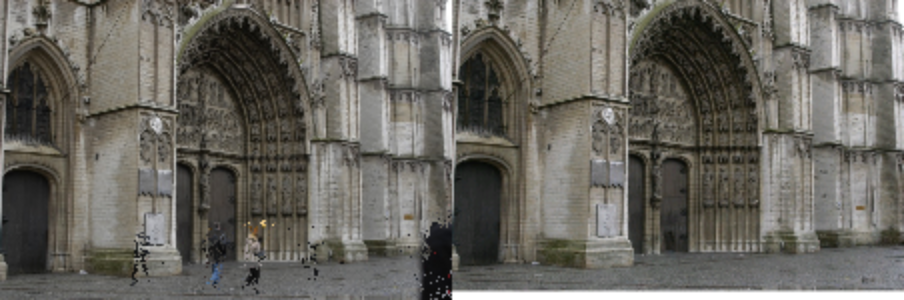


=== bin_size = 20 ===


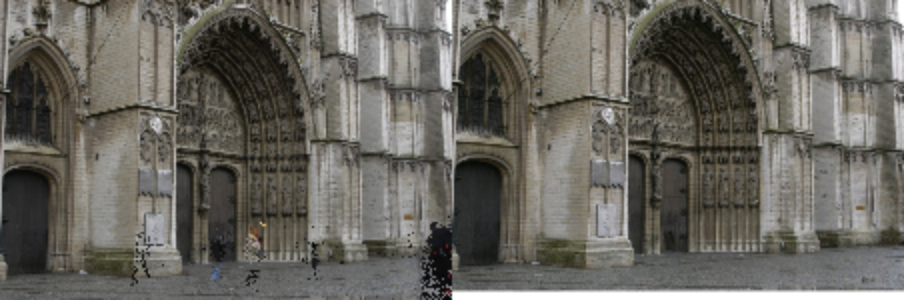


=== bin_size = 30 ===


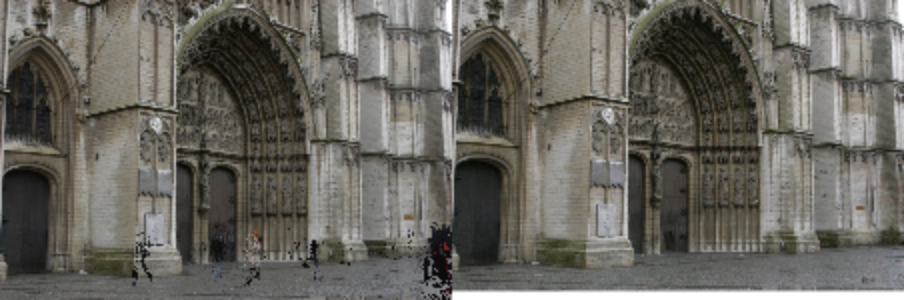


=== bin_size = 40 ===


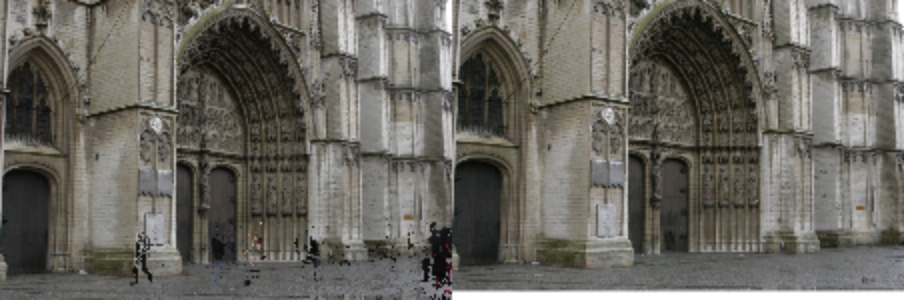


=== bin_size = 50 ===


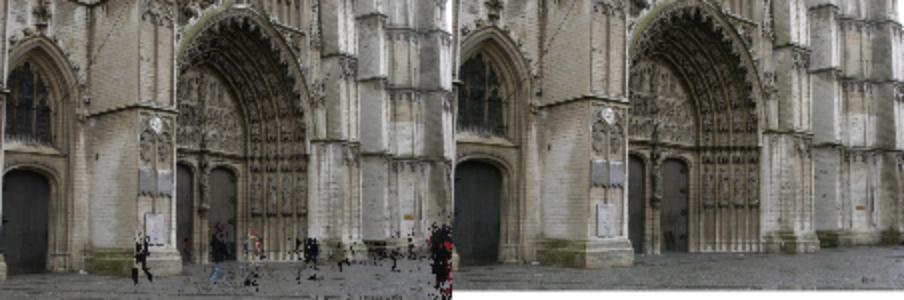


=== bin_size = 60 ===


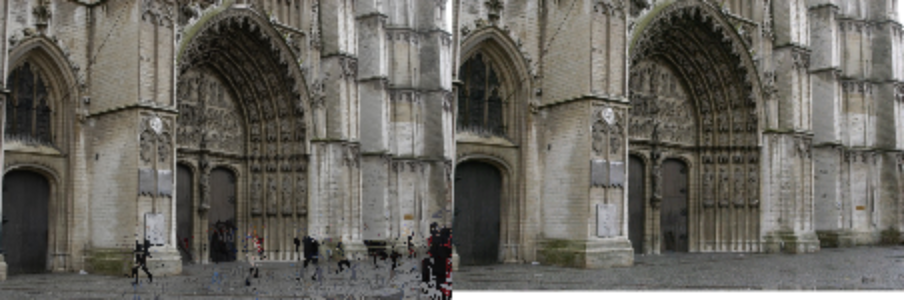


=== bin_size = 70 ===


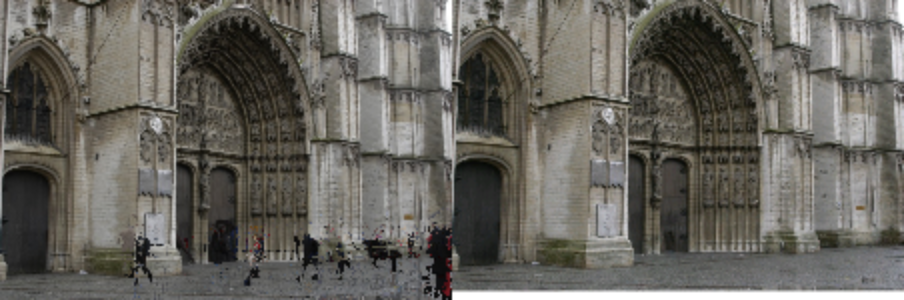


=== bin_size = 80 ===


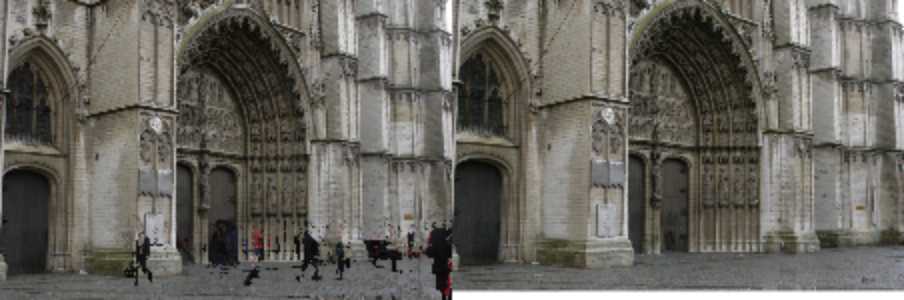


=== bin_size = 90 ===


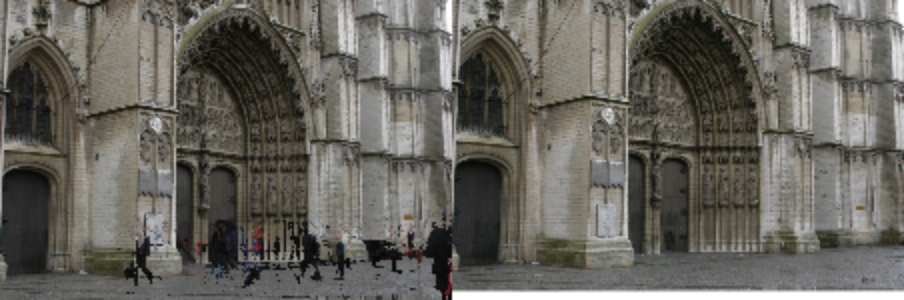


=== bin_size = 100 ===


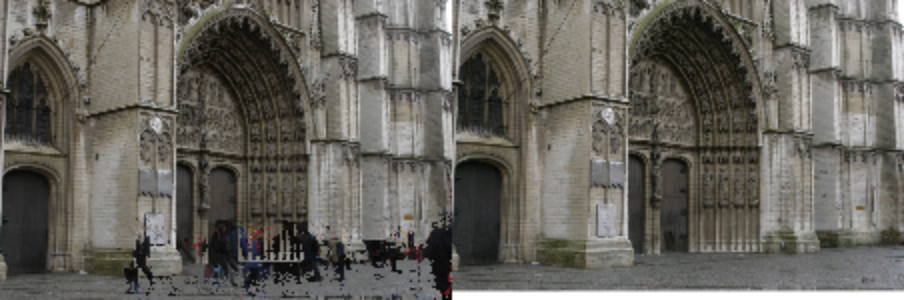

In [36]:
for bin_size in range(10, 101, 10):
    print(f"\n=== bin_size = {bin_size} ===")

    # Scalanie z aktualnym bin_size
    merged_majority = merge_by_majority2(cath_np, bin_size)

    # Dopasuj rozmiar cath_result jeśli potrzebne
    if merged_majority.shape != cath_result.shape:
        h, w = merged_majority.shape[:2]
        cath_result_resized = cv2.resize(cath_result, (w, h))
    else:
        cath_result_resized = cath_result

    # Połączenie obrazów w jeden
    combined = np.hstack([merged_majority, cath_result_resized])

    # Skalowanie (np. 2x)
    scale = 2.0
    combined_scaled = cv2.resize(combined, None, fx=scale, fy=scale)

    # Wyświetlenie
    imshow(combined_scaled)


Odnoszę wrażenie, że to nic nie dało...
w sensie, ta pętla, że niewiele to dało.

In [ ]:
def merge_by_majority3(images, bin_size=10):
    images = np.array(images)  # (N, H, W, C)
    N, H, W, C = images.shape
    result = np.zeros((H, W, C), dtype=np.uint8)

    # TODO!!!

    return result

In [ ]:
cath_np = np.stack(cath, axis=0)
merged_majority = merge_by_majority3(cath_np)

scale = 2.0
combined = np.hstack([merged_majority, cath_result])
combined_scaled = cv2.resize(combined, None, fx=scale, fy=scale)
print("\n===\nWynik scalania (max likelyhood) porównany z oczekiwanym, ale dla katedry, tylko z przybliżonymi kolorami:\n")
imshow(combined_scaled)